# Wellington: `ec_spectral` field-data example

Use `TaylorSwift.ec_spectral` to align CO₂ and vertical wind, fit cospectra,
inspect frequency response and ogives, and estimate spectral covariance corrections.
The input is the repository's `data/output/Wellington_filtered.parquet`.
The default selects 27 June 2024, 12:00–13:00 (file timestamps, no timezone conversion).

Install `pip install -e ".[notebooks]"` from the repository and run all cells in order.
Open from the repository or `examples/`. Only the selected columns and hour are
collected from the roughly 1 GB file. No download or source-file modification occurs.

Instrument geometry, response times, channel units, and gap tolerances below are
**example assumptions**, consistent with the other Wellington notebook; verify them
against deployment records before interpreting corrected values as field fluxes.

In [1]:
from pathlib import Path
from dataclasses import asdict, replace
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/TaylorSwift/ec_spectral.py").is_file())
sys.path.insert(0, str(ROOT / "src"))
from TaylorSwift import ec_spectral as ecs

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 1. Configure the interval and instrument

Averaging periods in this module are **seconds**. Wind is assumed m/s and
`CO2_density` mg/m³, so its covariance with wind is mg/m²/s. The 10 Hz grid
contains missing records; dropping them would compress time and distort the FFT.
We allow at least 85% original coverage and gaps no longer than 0.2 seconds.
Interpolation can suppress high-frequency energy; the instrument model does not
correct that loss. Additional MAD despiking is off because prior filtering is
unknown; enable it explicitly to explore its effect.

In [2]:
DATA_PATH = ROOT / "data/output/Wellington_filtered.parquet"
START = pd.Timestamp("2024-06-27 12:00:00")
END = pd.Timestamp("2024-06-27 13:00:00")  # exclusive
FS = 10.0
PERIOD_SECONDS = 1800
MIN_COVERAGE = 0.85
MAX_GAP_SECONDS = 0.2
DESPIKE = False
MAX_LAG_SECONDS = 0.5
CHANNELS = ["Ux", "Uy", "Uz", "CO2_density"]
SYSTEM = ecs.ECSystem(
    fs=FS, avg_period=PERIOD_SECONDS, z_ref=3.52, d=0.2,
    sonic_path=0.10, scalar_path=0.154, lateral_sep=0.0,
    tau_scalar=0.1, closed_path=False, scalar="co2", detrend="block",
)
OUTPUT = ROOT / "examples/outputs/wellington_ec_spectral"
display(pd.Series(asdict(SYSTEM), name="Example settings"))

fs                   10.0
avg_period           1800
z_ref                3.52
d                     0.2
sonic_path            0.1
scalar_path         0.154
lateral_sep           0.0
tau_sonic             0.0
tau_scalar            0.1
detrend             block
running_mean_tau    200.0
closed_path         False
tube_radius         0.003
tube_length           9.0
flow_rate             6.0
scalar                co2
Name: Example settings, dtype: object

## 2. Load the selected data and check timestamps

The time range must cover complete averaging blocks. Duplicate or off-grid
records stop the example instead of being silently discarded.

In [3]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Required local dataset: {DATA_PATH}")
period = pd.Timedelta(seconds=PERIOD_SECONDS)
step = pd.Timedelta(seconds=1 / FS)
if END <= START or (END - START) % period or START != START.floor(period):
    raise ValueError("Choose a positive range aligned to whole averaging blocks.")
scan = pl.scan_parquet(DATA_PATH)
required = ["TIMESTAMP", *CHANNELS]
missing = set(required) - set(scan.collect_schema().names())
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")
raw = (scan.select(required)
       .filter((pl.col("TIMESTAMP") >= START.to_pydatetime()) &
               (pl.col("TIMESTAMP") < END.to_pydatetime()))
       .collect().to_pandas().set_index("TIMESTAMP").sort_index())
if raw.empty or raw.index.has_duplicates or raw.index.hasnans:
    raise ValueError("Empty selection, duplicate timestamps, or invalid timestamps.")
if np.any((raw.index - START) % step != pd.Timedelta(0)):
    raise ValueError("Observed timestamps do not align with the configured sample grid.")
raw = raw.replace([-999.0, -9999.0, np.inf, -np.inf], np.nan)
print(f"Loaded {len(raw):,} rows; {raw.index.min()} to {raw.index.max()}")
display(raw.describe())
display(raw.index.to_series().diff().value_counts().rename("Observed time spacing"))

Loaded 32,400 rows; 2024-06-27 12:00:00.100000 to 2024-06-27 12:59:59.900000


,Ux,Uy,Uz,CO2_density
count,32400.000000,32400.000000,32400.000000,32400.000000
mean,-1.846581,-0.061619,0.050949,614.546068
std,1.550317,1.346436,0.319594,3.038943
min,-7.149508,-3.621891,-2.208647,560.019165
25%,-2.880995,-1.036579,-0.156765,613.270844
50%,-1.956801,-0.161283,0.038142,614.396790
75%,-0.703307,0.875108,0.243197,616.007172
max,2.950536,5.037725,1.977149,721.021729


TIMESTAMP
0 days 00:00:00.100000    28800
0 days 00:00:00.200000     3599
Name: Observed time spacing, dtype: int64

## 3. Restore only short gaps, optionally despike, and rotate

Coverage is evaluated per channel and block before filling. Interior gaps are
linearly interpolated; short edge gaps use the nearest observation. Replacement
counts from optional `ecs.despike` are reported separately. Double rotation makes
the mean lateral and vertical wind approximately zero.

In [4]:
def longest_run(mask):
    edges = np.diff(np.r_[False, mask, False].astype(int))
    lengths = np.flatnonzero(edges == -1) - np.flatnonzero(edges == 1)
    return int(lengths.max()) if lengths.size else 0

blocks, quality = [], []
for t0 in pd.date_range(START, END, freq=period, inclusive="left"):
    grid = pd.date_range(t0, t0 + period, freq=step, inclusive="left")
    block = raw.reindex(grid).copy()
    for col in CHANNELS:
        values = block[col].to_numpy(dtype=float)
        valid = np.isfinite(values)
        coverage = valid.mean()
        gap = longest_run(~valid) / FS
        if coverage < MIN_COVERAGE or gap > MAX_GAP_SECONDS + 1e-9:
            raise ValueError(f"{t0} {col}: coverage={coverage:.1%}, gap={gap:.2f}s; "
                             "choose another period or review the gap policy.")
        filled = np.interp(np.arange(len(values)), np.flatnonzero(valid), values[valid])
        cleaned = ecs.despike(filled, window=int(60 * FS)) if DESPIKE else filled.copy()
        if not np.isfinite(cleaned).all():
            raise ValueError(f"Nonfinite values after despiking {col} at {t0}")
        quality.append(dict(interval=t0, channel=col, coverage=coverage,
                            filled=int((~valid).sum()), longest_gap_s=gap,
                            despiked=int(np.count_nonzero(cleaned != filled))))
        block[col] = cleaned
    u, v, w = ecs.double_rotation(block.Ux, block.Uy, block.Uz)
    np.testing.assert_allclose([v.mean(), w.mean()], 0, atol=1e-10)
    blocks.append(dict(start=t0, u=u, v=v, w=w, c=block.CO2_density.to_numpy()))
quality_table = pd.DataFrame(quality)
display(quality_table)

,interval,channel,coverage,filled,longest_gap_s,despiked
0,2024-06-27 12:00:00,Ux,0.9,1800,0.1,0
1,2024-06-27 12:00:00,Uy,0.9,1800,0.1,0
2,2024-06-27 12:00:00,Uz,0.9,1800,0.1,0
3,2024-06-27 12:00:00,CO2_density,0.9,1800,0.1,0
4,2024-06-27 12:30:00,Ux,0.9,1800,0.1,0
5,2024-06-27 12:30:00,Uy,0.9,1800,0.1,0
6,2024-06-27 12:30:00,Uz,0.9,1800,0.1,0
7,2024-06-27 12:30:00,CO2_density,0.9,1800,0.1,0


## 4. Align the scalar, compute cospectra, and fit the central band

Positive lag means CO₂ trails wind. `shift` fills exposed edges; we trim those
artificial samples before the FFT and use the retained duration for the model.
A peak at the search boundary is flagged for review. Maximizing absolute
correlation is a diagnostic, especially when covariance is weak.

Use block detrending consistently with the modeled averaging response. The raw
cospectrum integrates to the unwindowed, detrended population covariance; binned
values are for plotting and fitting. Failed fits stop with the affected interval.
A model's R² alone does not establish stationarity or suitability for correction.

In [5]:
analyses, rows = [], []
for block in blocks:
    w, c = block["w"], block["c"]
    lag, lags_s, correlation = ecs.find_lag(w, c, FS, max_lag_s=MAX_LAG_SECONDS)
    aligned = ecs.shift(c, lag)
    keep = slice(None, -lag) if lag > 0 else slice(-lag, None) if lag < 0 else slice(None)
    w, aligned = w[keep], aligned[keep]
    system = replace(SYSTEM, avg_period=len(w) / FS)
    wind = float(np.hypot(block["u"][keep], block["v"][keep]).mean())
    if not np.isfinite(wind) or wind <= 0:
        raise ValueError(f"Invalid mean wind at {block['start']}")
    try:
        co = ecs.cospectrum(w, aligned, FS, detrend="block")
        fit = ecs.fit_cospectrum(co["f_bin"], co["fCo_bin"], FS, system.avg_period)
    except (ValueError, RuntimeError) as exc:
        raise ValueError(f"Spectral analysis failed at {block['start']}: {exc}") from exc
    np.testing.assert_allclose(co["Co"].sum() * FS / co["N"], co["cov"], rtol=1e-10)
    np.testing.assert_allclose(co["ogive"][0], 1.0, rtol=1e-10)
    eta_x = fit["fx"] * system.zd / wind
    boundary = bool(np.isclose(abs(lag / FS), MAX_LAG_SECONDS))
    analyses.append(dict(co=co, fit=fit, system=system, wind=wind,
                         lag=lag, lags_s=lags_s, correlation=correlation, eta_x=eta_x))
    rows.append(dict(interval=block["start"], samples=co["N"], duration_s=system.avg_period,
                     wind_m_s=wind, lag_s=lag / FS, lag_at_boundary=boundary,
                     peak_abs_r=float(np.nanmax(np.abs(correlation))),
                     covariance=co["cov"], fx_hz=fit["fx"], mu=fit["mu"],
                     r2=fit["r2"], eta_x=eta_x,
                     inertial_slope=ecs.inertial_slope(co["f_bin"], co["fCo_bin"],
                                                      3 * fit["fx"], FS / 4)))
summary = pd.DataFrame(rows).set_index("interval")
display(summary)

,samples,duration_s,wind_m_s,lag_s,lag_at_boundary,peak_abs_r,covariance,fx_hz,mu,r2,eta_x,inertial_slope
interval,,,,,,,,,,,,
2024-06-27 12:00:00,18000,1800.0,2.309709,0.0,False,0.234529,-0.226208,0.051611,0.219505,0.064741,0.074186,-0.514008
2024-06-27 12:30:00,18000,1800.0,2.596127,0.0,False,0.170983,0.128673,0.074157,0.241542,0.070478,0.094834,-0.751572


## 5. Compare correction estimates

Apply factors to **covariances before WPL density correction**. No WPL correction
is applied here. Check the file's processing history to avoid a second correction.
Integral factors use the fitted peak and broadness; analytical factors use
equivalent time constants. They use different approximations and need not agree.
`dF_rel` is analytical model sensitivity, not a fit confidence interval.
Factors above 1.5 are marked for review, not clipped.

In [6]:
corrections = []
for a in analyses:
    s, fit, wind = a["system"], a["fit"], a["wind"]
    taus = ecs.equivalent_time_constants(s, wind)
    integral = ecs.correction_factor_integral(s, wind, fx=fit["fx"], mu=fit["mu"])
    analytical = float(ecs.correction_factor_analytical(fit["fx"], taus["tau_b"], taus["tau_e"]))
    uncertainty = float(ecs.correction_uncertainty(fit["fx"], taus["tau_b"], taus["tau_e"]))
    corrections.append(dict(F_integral=integral, F_analytical=analytical, dF_rel=uncertainty,
                            modeled_loss_percent=100 * (1 - 1 / integral),
                            covariance_integral=a["co"]["cov"] * integral,
                            covariance_analytical=a["co"]["cov"] * analytical,
                            factor_review=not np.isfinite([integral, analytical]).all()
                                          or max(integral, analytical) > 1.5))
results = summary.join(pd.DataFrame(corrections, index=summary.index))
display(results)

,samples,duration_s,wind_m_s,lag_s,lag_at_boundary,peak_abs_r,covariance,fx_hz,mu,r2,eta_x,inertial_slope,F_integral,F_analytical,dF_rel,modeled_loss_percent,covariance_integral,covariance_analytical,factor_review
interval,,,,,,,,,,,,,,,,,,,
2024-06-27 12:00:00,18000,1800.0,2.309709,0.0,False,0.234529,-0.226208,0.051611,0.219505,0.064741,0.074186,-0.514008,1.055830,1.038212,0.034978,5.287817,-0.238837,-0.234852,False
2024-06-27 12:30:00,18000,1800.0,2.596127,0.0,False,0.170983,0.128673,0.074157,0.241542,0.070478,0.094834,-0.751572,1.062569,1.051035,0.042791,5.888440,0.136724,0.135240,False


## 6. Inspect the diagnostic plots

Select either half-hour below. Gray crosses in the normalized cospectrum denote
negative bins shown by magnitude. The ogive accumulates from high to low frequency;
its endpoint of one is enforced by normalization, so inspect its shape and
low-frequency plateau rather than treating that endpoint as a stationarity test.
The slope reference is −4/3 for frequency-weighted cospectra. Noise, interpolation,
and model assumptions can affect the tail. The Kaimal overlay assumes neutral
stability; the correction-versus-wind panel holds this interval's fitted `eta_x`
fixed and is an illustrative sensitivity comparison, not a site calibration.

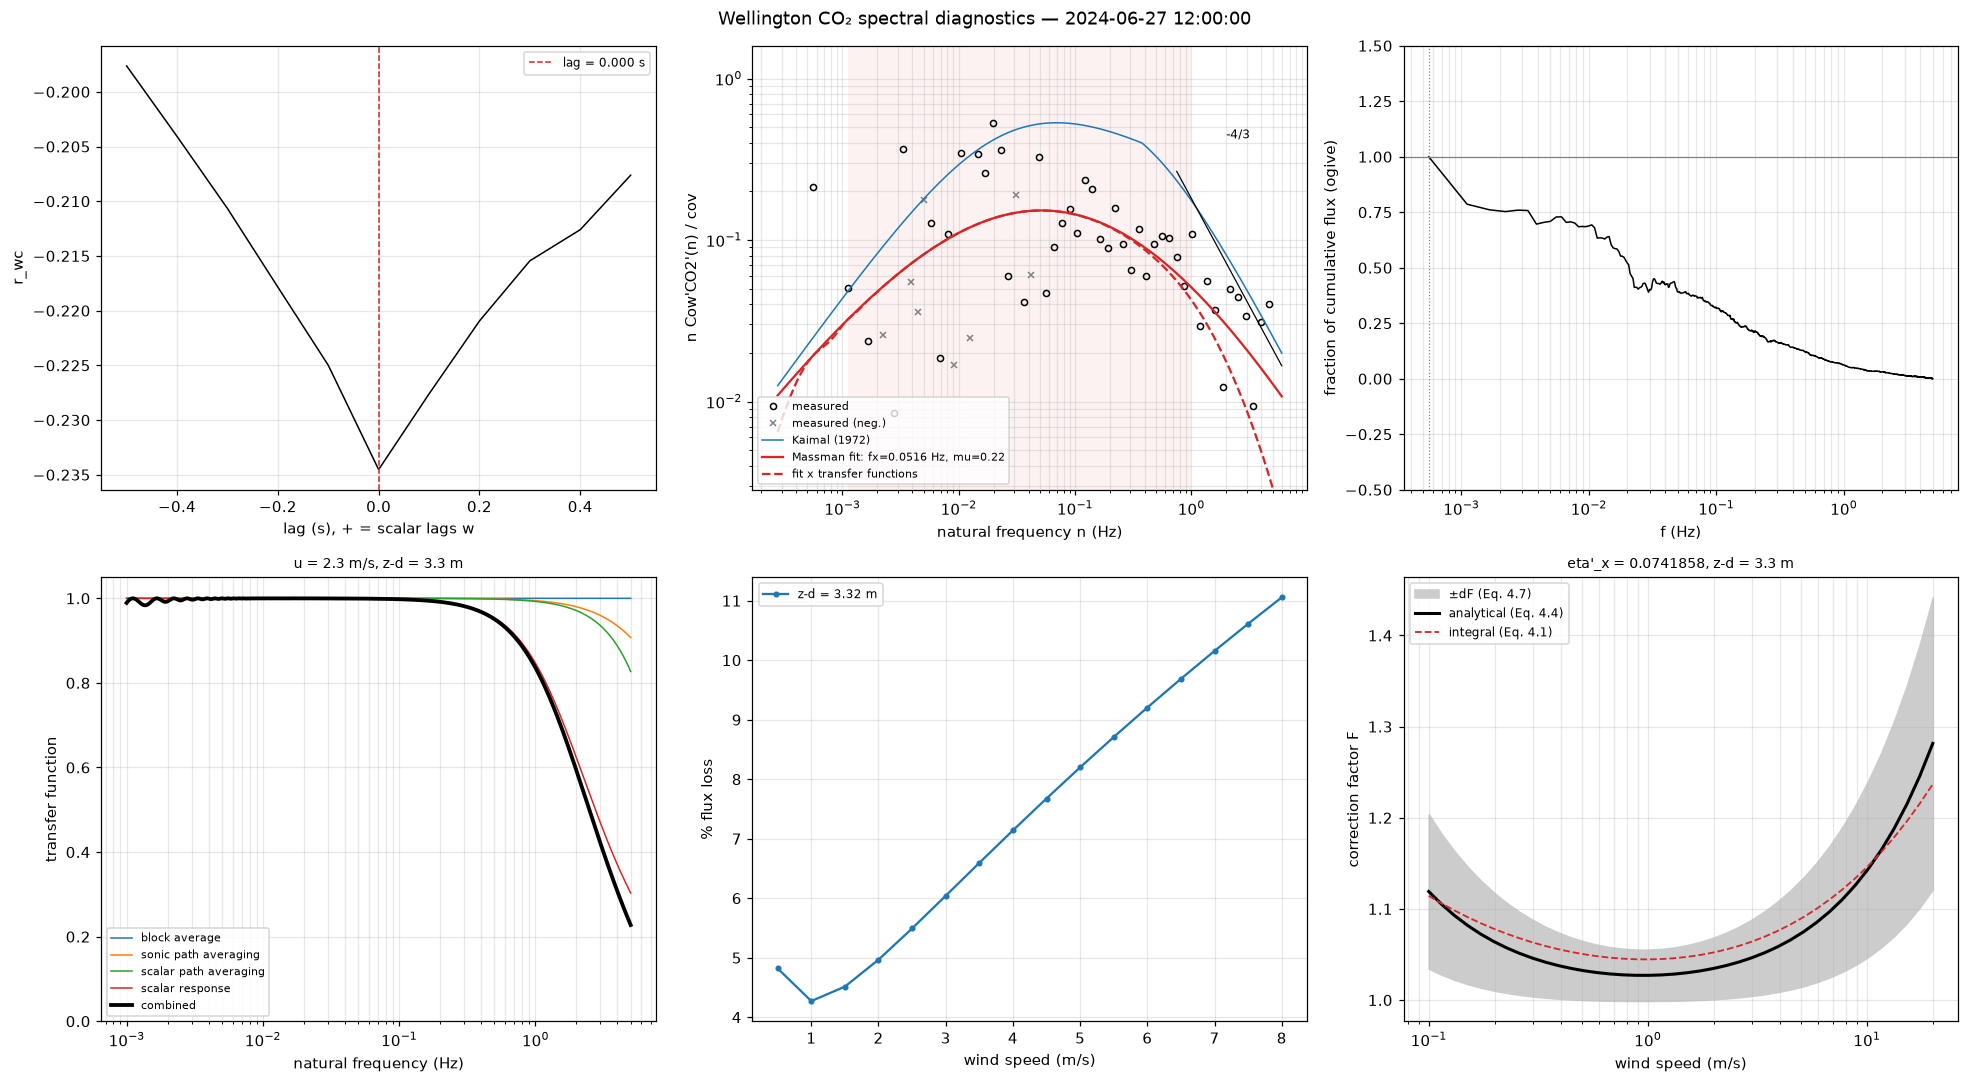

In [7]:
PLOT_INTERVAL = 0
selected = analyses[PLOT_INTERVAL]
a = selected
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ecs.plot_lag(a["lags_s"], a["correlation"], ax=axes[0, 0])
ecs.plot_cospectrum(a["co"], a["fit"], a["system"], a["wind"], ax=axes[0, 1], label="w'CO2'")
ecs.plot_ogive(a["co"], ax=axes[0, 2])
ecs.plot_transfer_functions(a["system"], a["wind"], ax=axes[1, 0])
ecs.plot_flux_loss(a["system"], ax=axes[1, 1], model="massman",
                   eta_x=a["eta_x"], mu=a["fit"]["mu"])
ecs.plot_correction_vs_wind(a["system"], a["eta_x"], ax=axes[1, 2], mu=a["fit"]["mu"])
fig.suptitle(f"Wellington CO₂ spectral diagnostics — {results.index[PLOT_INTERVAL]}")
fig.tight_layout()
plt.show()

## 7. Export the example results

Rerunning this cell replaces only this example's outputs. Export raw frequency
bins for integration, the diagnostic figure, coverage records, fit/correction
summaries, and settings for reproducibility. Review boundary lags, weak correlations,
poor fits, and large factors before using any corrected covariance. Estimating a
site-wide peak-frequency relationship requires many suitable intervals.

In [8]:
OUTPUT.mkdir(parents=True, exist_ok=True)
results.to_csv(OUTPUT / "interval_results.csv")
quality_table.to_csv(OUTPUT / "coverage.csv", index=False)
spectra = pd.concat([
    pd.DataFrame({"interval": results.index[i], "frequency_hz": a["co"]["f"],
                  "cospectrum": a["co"]["Co"], "ogive": a["co"]["ogive"]})
    for i, a in enumerate(analyses)
], ignore_index=True)
spectra.to_parquet(OUTPUT / "cospectra.parquet", index=False)
fig.savefig(OUTPUT / "diagnostics.png", dpi=150, bbox_inches="tight")
plt.close(fig)
settings = dict(data_path=str(DATA_PATH), start=START.isoformat(), end=END.isoformat(),
                system=asdict(SYSTEM), minimum_coverage=MIN_COVERAGE,
                max_gap_seconds=MAX_GAP_SECONDS, despike=DESPIKE,
                max_lag_seconds=MAX_LAG_SECONDS, detrend="block", taper=True,
                plot_interval=PLOT_INTERVAL)
(OUTPUT / "settings.json").write_text(json.dumps(settings, indent=2), encoding="utf-8")
print(f"Saved results to {OUTPUT}")

Saved results to C:\Users\paulinkenbrandt\Documents\Github\TaylorSwift\examples\outputs\wellington_ec_spectral


## Reading the executed example

For the default hour, both intervals select zero lag. Their fitted R² values are
approximately 0.065 and 0.070: the smooth model explains little of the observed
binned variability. The illustrative integral factors are about 1.056 and 1.063,
but small factors do not validate poor fits. These are workflow demonstrations,
not validated field corrections. Review additional intervals, stationarity,
filtering history, and instrument metadata before calibrating a site model.
These observations describe the saved default run; recompute them if you change
its settings or time range.